the inital theta is 
[[0.01300189]
 [1.45353408]]
The prediction is 
[[1.10181554]
 [2.77679318]
 [2.14095817]
 [1.75334291]
 [0.46655871]
 [0.46648859]
 [0.18185491]
 [2.53103498]
 [1.7604842 ]
 [2.07141713]
 [0.07284242]
 [2.83259594]
 [2.43296938]
 [0.63028616]
 [0.54157946]
 [0.5461713 ]
 [0.89745483]
 [1.5385046 ]
 [1.2686955 ]
 [0.85962485]
 [1.79169996]
 [0.41852005]
 [0.8622863 ]
 [1.07804074]
 [1.33882842]
 [2.29556192]
 [0.59346719]
 [1.50791645]
 [1.73519142]
 [0.14803641]
 [1.77917618]
 [0.50872714]
 [0.20211131]
 [2.77147682]
 [2.82016002]
 [2.36306808]
 [0.89853488]
 [0.29694138]
 [2.00211393]
 [1.29255519]
 [0.36777536]
 [1.45251492]
 [0.11297167]
 [2.65645827]
 [0.76529294]
 [1.93899933]
 [0.91916723]
 [1.52487507]
 [1.60232593]
 [0.55038639]
 [2.83165049]
 [2.26636584]
 [2.74418935]
 [2.61432599]
 [1.75113788]
 [2.69295312]
 [0.27025563]
 [0.58273743]
 [0.1444807 ]
 [0.95875934]
 [1.14291326]
 [0.80183202]
 [2.42219831]
 [1.05010813]
 [0.82969766]
 [1.59065639]
 [0.422

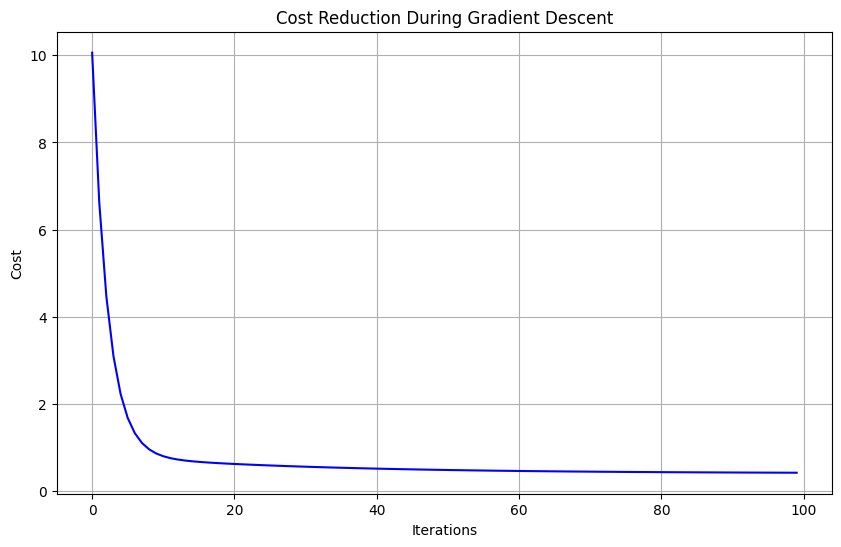

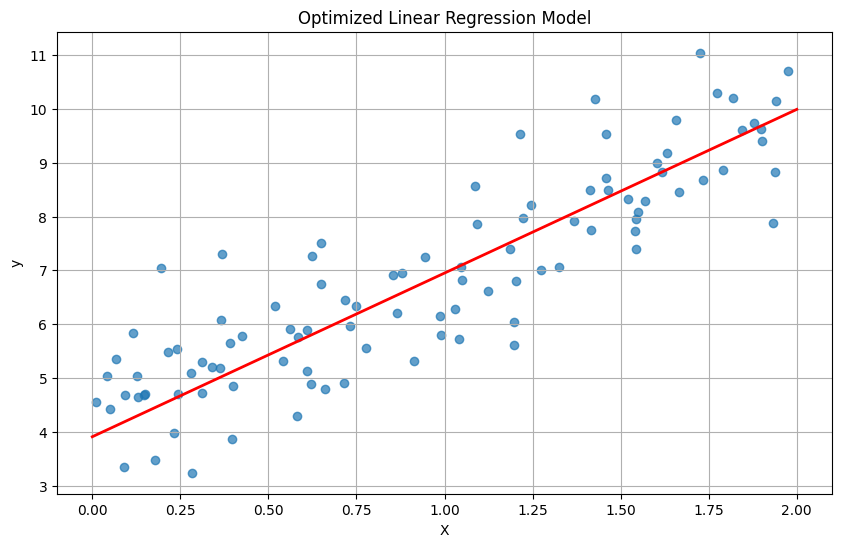

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.theta = None
        self.cost_history = []
    
    def compute_cost(self, X, y):
        """Calculate MSE cost function"""
        m = len(y)
        predictions = X.dot(self.theta)
        errors = predictions - y
        return (1/(2*m)) * np.sum(errors**2)
    
    def fit(self, X, y):
        """Perform gradient descent to minimize cost"""
        # Add intercept term (x0 = 1)
        X = np.c_[np.ones((X.shape[0], 1)), X]
        
        # Initialize parameters
        self.theta = np.random.randn(X.shape[1], 1)
        m = len(y)
        
        print("the inital theta is ")
        print(self.theta)
        for _ in range(self.n_iter):
            predictions = X.dot(self.theta)
            print("The prediction is ")
            print(predictions)
            errors = predictions - y.reshape(-1,1)
            print("The error is ")
            print(errors)
            # Compute gradients
            gradients = (1/m) * X.T.dot(errors)
            print("The gradient is ")
            print(gradients)
            
            # Update parameters
            self.theta -= self.learning_rate * gradients
            print("The new theta is ")
            print(self.theta)
            # Store cost history
            self.cost_history.append(self.compute_cost(X, y))
            
        return self
    
    def predict(self, X):
        """Make predictions using optimized parameters"""
        X = np.c_[np.ones((X.shape[0], 1)), X]
        return X.dot(self.theta)

# Generate sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Initialize and train model
model = LinearRegressionGD(learning_rate=0.1, n_iter=100)
model.fit(X, y)

# Results
print("Optimized parameters:")
print(f"θ0 (intercept): {model.theta[0][0]:.4f}")
print(f"θ1 (slope): {model.theta[1][0]:.4f}")
print(f"Final cost: {model.cost_history[-1]:.4f}")

# Plot cost convergence
plt.figure(figsize=(10,6))
plt.plot(range(model.n_iter), model.cost_history, 'b-')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Reduction During Gradient Descent')
plt.grid(True)
plt.show()

# Make prediction example
X_new = np.array([[0], [2]])
y_pred = model.predict(X_new)

# Plot regression line
plt.figure(figsize=(10,6))
plt.scatter(X, y, alpha=0.7)
plt.plot(X_new, y_pred, 'r-', linewidth=2)
plt.title('Optimized Linear Regression Model')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()